In [1]:
from matplotlib import pyplot as plt

import numpy as np
from scipy.integrate import solve_ivp
from sklearn.linear_model import Ridge
from types import SimpleNamespace as sn
from tqdm import trange
from copy import deepcopy
from datetime import datetime
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from matplotlib.widgets import Button, Slider
import pandas as pd



from simulator import find_npzs



# Concepts

## Ensamble Average
Essentially the expected value for a stochastic thingymabob

## Determinent
(2D) The transformation matrix for a vector such that area is 0. Think about squiching the two $\hat{i}$ and $\hat{j}$ onto the same line

## Eigenvectors and Eigenvalues
The line on which a given vector stays on its span after transformation; doesn't rotate, but does scale.<br>
An Eigenvector $\vec{v}$ is any vector for which above is true (given some transformation matrix $A$), and the amount the vector is scaled, is the Eigenvalue $\lambda$
### $A\vec{v}=\lambda\vec{v}$
where $A$ is the transformation matrix, $\vec{v}$ is the eigenvector, and $\lambda$ is the eigen value<br>
equation states that the matrix-vector multiplication $A\vec{v}$ gives the same as a simple scalar multiplication $\lambda\vec{v}$.
<br>
Working with the equation above isn't intuitive because the left side represents a matrix multiplication, and the right side, a scalar multiplication.
<br> Thus, representing $\lambda$ as a matrix (for which only scaling by lambda occurs) makes it simpler:<br>
$\begin{bmatrix}\lambda & 0 & 0\\0 & \lambda & 0\\0 & 0 & \lambda\end{bmatrix} = \lambda\begin{bmatrix}1 & 0 & 0\\0 & 1 & 0\\0 & 0 & 1\end{bmatrix}$
<br>
### $A\vec{v}=(\lambda I)\vec{v}$
### $A\vec{v}-(\lambda I)\vec{v} = \vec{0}$
### $\vec{v}(A-\lambda I) = \vec{0}$

$\vec{v}(A-\lambda I) \rightarrow \begin{bmatrix} a-\lambda & b & c\\d & e-\lambda & f\\g & h & i-\lambda\end{bmatrix}$
<br>$\therefore$ We're looking for a vector ($\vec{v}$) which when multiplied with above gives the 0 vector.
### $\vec{v} \begin{bmatrix} a-\lambda & b & c\\d & e-\lambda & f\\g & h & i-\lambda\end{bmatrix} = \vec{0}$
<br>

if we want the product of a non 0 vector $\vec{v}$ and a matrix to equal 0, we need the determinent of the matrix to be 0. Or in other words, the matrix needs to squish the space into a lower dimension.

[Video visualising this effect](https://youtu.be/PFDu9oVAE-g?t=457)

## Eigendecomposition
https://www.youtube.com/watch?v=KTKAp9Q3yWg
Useful for when you need to multiply a matrix by itself. If a matrix has some eigenvector(s), we can simplify process

## Replica Definition
A replica in this case is some theoretical arbitrary run of the simulation, which shares it's input signal with the set of replicas, but has different starting conditions otherwise.
<br>
### $x(t) = s(t) + n(t)$
where $x(t)$ is the response signal of a replica at time $t$, in other words, the state of the simulation; the boid positions and velocities,<br>
where $n(t)$ is the noise, the unexpected/chaotic portion of the signal<br>
where $s(t)$ is the signal component, the expected portion of the signal (see more in next section).

## Signal Component
Specifically, the signal component $s(t)$ is the *ensamble average* state of a replica at time $t$. If we imagine it as discrete opposed to continuos, it's the largest bin if we were to binomially distribute the possible states at $t$.

### Finding the ensamble average
The state of the reservoir for a given time $t$ and number of boids $N$, has two componenets, its velocity and position: $v(t),p(t) \in R^{ND}$<br>
We can concatinate these two into a single state space $x(t) = \begin{bmatrix} p(t)\\ v(t)\end{bmatrix} \in R^{ND}$
<br>
Thus, finding the ensamble average: 
#### $\langle x(t) \rangle = \frac{1}{R} \sum\limits_{r}^{R} x_r(t)\\ \therefore \\s(t) = \frac{1}{R} \sum\limits_{r}^{R} x_r(t)$

where R is the total number of replicas.

In [ ]:
path = ['tests/random_positions/']
datas = find_npzs(path)

['tests/random_positions/1000s113.npz', 'tests/random_positions/1000s675.npz', 'tests/random_positions/1000s661.npz', 'tests/random_positions/1000s107.npz', 'tests/random_positions/1000s649.npz', 'tests/random_positions/1000s891.npz', 'tests/random_positions/1000s885.npz', 'tests/random_positions/1000s852.npz', 'tests/random_positions/1000s846.npz', 'tests/random_positions/1000s477.npz', 'tests/random_positions/1000s311.npz', 'tests/random_positions/1000s305.npz', 'tests/random_positions/1000s463.npz', 'tests/random_positions/1000s339.npz', 'tests/random_positions/1000s10.npz', 'tests/random_positions/1000s488.npz', 'tests/random_positions/1000s38.npz', 'tests/random_positions/1000s503.npz', 'tests/random_positions/1000s265.npz', 'tests/random_positions/1000s271.npz', 'tests/random_positions/1000s517.npz', 'tests/random_positions/1000s1027.npz', 'tests/random_positions/1000s259.npz', 'tests/random_positions/1000s1033.npz', 'tests/random_positions/1000s8.npz', 'tests/random_positions/10

In [ ]:
datas

200

# Reservoir Profiling/Consistency Analysis

## Consistency Profile


## Finding the signal
where the ensamble **signal** $s$ is some average state of the reservoir at a given time $t$.<br>
Where we do many different simulations with different starting conditions (replicas), and by "averaging" the state of each replica at a given time $t$,<br>
we gain an understanding of what the *default* state is for the reservoir at a given $t$, given the same inputs (same lorenz)<br>




In [ ]:
NUM_REPLICAS = 10
TIME_STEPS = 100

sim = Simulator.run_simulation
load_params = Simulator.load_ini

## Consistency Correlation
### $\gamma^2 = \frac{\langle s^2 \rangle}{\langle (s+n)^2\rangle}$
(where the angled brackets are the inner product of presumably two vectors)<br>
Each replica may be decomposed into a signal and a noise component<br>where typically $i=2$, as to say there are two responses (Lymburn makes this assertion) <br>
$x_i(t) = s_i(t) + n_i(t)$<br>
$x_i(t) = s_i(t) + n_i(t)$<br>
The signal component $s(t)$ is defined as the ensemble average of an infinite number of replicas,<br>
and the noise $n(t)$ component is defined as the remainder for each replica.<br>
<br>
x is the reservoir state $\therefore$ positions and vectors of the swarm.
<br>

# Observation Layer

## Kernel Function Definition

### $\Psi_m(x) = e^{-\frac{(x-c_m)^2}{2w_m}}$
M 
where $m = 1,2,. . .,M$ is the number of kernels, where, $c_m$ and $w_m$ are the location and width of the kernels.

Kernels measure the velocities and positions of the agents in order to obtain the following observations:
#### $r_1,m(t) = \sum\limits_{i=1}^{N}\Psi_m(x_i(t))$, counts the number of agents in the kernel
#### $r_2,m(t) = \sum\limits_{i=1}^{N}\Psi_m(x_i(t))v_{xi}(t)$, average velocity near center of kernel??
#### $r_3,m(t) = \sum\limits_{i=1}^{N}\Psi_m(x_i(t))v_{yi}(t)$ average velocity near center of kernel??

## Kernel Function Implementation

**Determining location and width of a kernel**
Random agent + random time, position of the agent gives center of the kernel $c_m$.
Width is set to the distance to the 5 closest neighbour.

In [2]:
path = ['tests/random_positions/']
datas = find_npzs(path)

Loaded 1058 run(s)


In [3]:
KERNELS_NUMBER=200
indexes = range(KERNELS_NUMBER)
print(indexes)

range(0, 200)


In [4]:
def neighbour_distances(positions, agents:int|list[int] = None):
    '''
        Two functionalities:\n
            (1) Given no index
                where N=len(positions), the number of agents
                if index is left empty, return a matrix of shape [N, N-1]], 
                where columns are each agent, and the rows are the ordered distance to each neighbour. e.g.
                [0][33,5,22...,N-1]
                [1][6,5,13...,N-1]
                .
                .
                .
                [N][41,17,83...,N-1]

            (2) If an index (or multiple) are given, a(these) specific row(s) of the matrix described above is(are) returned 
                i.e. for a(the) specific agent(s)
    '''
    if agents is None:
        indexes = np.array([i for i in range(len(positions))])
    elif isinstance(agents,list):
        indexes = agents
    elif isinstance(agents,int):
        indexes = [agents]
        

    distances = np.array([[None]*len(positions)]*len(positions))
    for i in indexes:
        diff = positions - positions[i]
        distances[i] = np.linalg.norm(diff,axis=1)

    return distances

def get_closest_neighbours(ordered,closest_num):
    '''
        :params:
            ordered: 
                An array of agent distances from a given index x ordered[x] will equal 0 (distance from self).
                All other elements in the correspond to their distance from the agent represented by index x.
        :return: array length $closest_num$ of agent indexes ordered from closest to furthest
    '''

    #This system is kind of agnostic to duplicate distances. Whilst it's unlikely, in the case of it occuring it wouldn't be a big deal
    dictionaried = {distance:i for i,distance in enumerate(ordered)}
    smallest_to_biggest = np.sort(ordered,kind='quicksort')
        
    closest_agents = [dictionaried[i] for i in smallest_to_biggest[1:closest_num+1]]
    return closest_agents


$\Psi_m(x) = e^{-\frac{(x-c_m)^2}{2w_m}}$

$r_1,m(t) = \sum\limits_{i=1}^{N}\Psi_m(x_i(t))$

$r_2,m(t) = \sum\limits_{i=1}^{N}\Psi_m(x_i(t))v_{xi}(t)$

$r_3,m(t) = \sum\limits_{i=1}^{N}\Psi_m(x_i(t))v_{yi}(t)$

In [5]:
def kernel_function(x_i,c_m,w_m):
    ''':returns: kernal for a '''

    numer = -np.linalg.norm(x_i-c_m)**2
    denom = 2 * w_m
    return np.exp(numer/denom)

def receptive_field_1(x,time_step,kernels):# x is of course positions
    '''
        Sensitive to the boid positions
    '''
    r1 = []
    for c_m,w_m in kernels:
        r1_m = 0
        for x_i in x[time_step]:
            r1_m += kernel_function(x_i,c_m,w_m)
        r1.append(r1_m)

    return r1

def receptive_field_2(x,v,time_step, kernels):
    '''
        Sensitive to the boid positions as a product of their x velocity
    '''
    velocities_x = v[time_step,:,0]
    positions = x[time_step]

    r2 = []
    for c_m, w_m in kernels:
        r2_m = 0
        for x_i,v_i in zip(positions,velocities_x):
            r2_m += kernel_function(x_i,c_m,w_m) * v_i
        r2.append(r2_m)

    return r2

def receptive_field_3(x,v,time_step,kernels):
    '''
        Sensitive to the boid positions as a product of their y velocity
    '''
    velocities_y = v[time_step,:,1]
    positions = x[time_step]

    r3 = []
    for c_m, w_m in kernels:
        r3_m = 0
        for x_i,v_i in zip(positions,velocities_y):
            r3_m += kernel_function(x_i,c_m,w_m) * v_i
        r3.append(r3_m)
    
    return r3


def calculate_receptive_fields(kernels,x,v,time_step,num_boids):
    
    r1 = []
    r2 = []
    r3 = []

    velocities = v[time_step]
    positions = x[time_step]

    for c_m, w_m in kernels:
        r1_m = 0
        r2_m = 0
        r3_m = 0

        for x_i, (vx_i, vy_i) in zip(positions, velocities):
            psi = kernel_function(x_i,c_m,w_m)

            r1_m += psi
            r2_m += psi * vx_i
            r3_m += psi * vy_i
        
        r1.append(r1_m/num_boids)
        r2.append(r2_m/num_boids)
        r3.append(r3_m/num_boids)

    return r1,r2,r3

In [6]:
def generate_kernels(run):
    kernels = [None] * KERNELS_NUMBER
    for m in range(KERNELS_NUMBER):
        # below could theoretically be put into one line but seperated it all out for readability

        random_time = np.random.randint(0,run['time_steps']) # selects a random t in the range of time steps of the run
        xs_at_random_time = run['positions'][random_time] # selects the position array at the random time step

        random_agent_index = np.random.randint(0,run['boid_count']) # selects a random vector position index at the time step (a given agent)

        neigh_dist_matrix = neighbour_distances(xs_at_random_time,random_agent_index) # create a matrix finding random_agent's distance to all other agents
        fifth_closest = get_closest_neighbours(neigh_dist_matrix[random_agent_index],5)[-1] # find the closest 5 agents to random_agent, index the last one to get the '5th closest' in a sense

        distance_to_fith = np.linalg.norm(xs_at_random_time[random_agent_index] - xs_at_random_time[fifth_closest])
        c_m = xs_at_random_time[random_agent_index] # some random agent
        w_m = distance_to_fith # the fifth closest agent to said random agent
        kernels[m] = [c_m,w_m]
    
    return kernels


    

In [22]:
def draw_kernals(ax,kernels):
    for k in kernels:
        ax.add_artist(plt.Circle(k[0], k[1], fill=False,alpha=0.3))
    return ax

In [ ]:
kernels = generate_kernels(run) 


fig, ax = plt.subplots()

ax.set_xlim([-10,10])
ax.set_ylim([-10,10])
ax.set_aspect(1)
draw_kernals(ax,kernels)

plt.title('Kernels')
plt.show()


In [70]:
print(run.keys())

dict_keys(['positions', 'velocities', 'predator_positions', 'time_steps', 'boid_count', 'bounds', 'config_title'])


# Observing a run

In [ ]:
# for each time step, take a read out from each kernel

def get_kernel_rervoir_state(run):
    kernels = generate_kernels(run)

    x = run['positions']
    v = run['velocities']

    r1 = []
    r2 = []
    r3 = []

    for t in trange(run['time_steps']):
        r1_t, r2_t, r3_t = calculate_receptive_fields(kernels,x,v,t,run['boid_count'])
        r1.append(r1_t)
        r2.append(r2_t)
        r3.append(r3_t)

    return np.concatenate([r1,r2,r3],axis=1)


In [8]:
np.random.seed(1)

def kernel_reservoir_prediction(training_reservoir_state, testing_reservoir_state, lorenz,ridge_beta):
    lorenz_x = lorenz[:,0]
    targets_x = np.roll(lorenz_x,-1)
    targets_x = targets_x[:-1]

    training_reservoir_state = training_reservoir_state[:-1]

    ridge = Ridge(alpha=ridge_beta,fit_intercept=False)
    ridge.fit(training_reservoir_state,targets_x)
    
    return ridge.predict(testing_reservoir_state[:-1])
    

In [9]:
random_run_index = np.random.randint(0,len(datas)-1)
training_run = datas[random_run_index]

random_run_index = np.random.randint(0,len(datas)-1)
testing_run = datas[random_run_index]

r_train = get_kernel_rervoir_state(training_run)
r_test = get_kernel_rervoir_state(testing_run)

lorenz = training_run['predator_positions']

100%|██████████| 1000/1000 [01:31<00:00, 10.99it/s]


2.4055072454181845


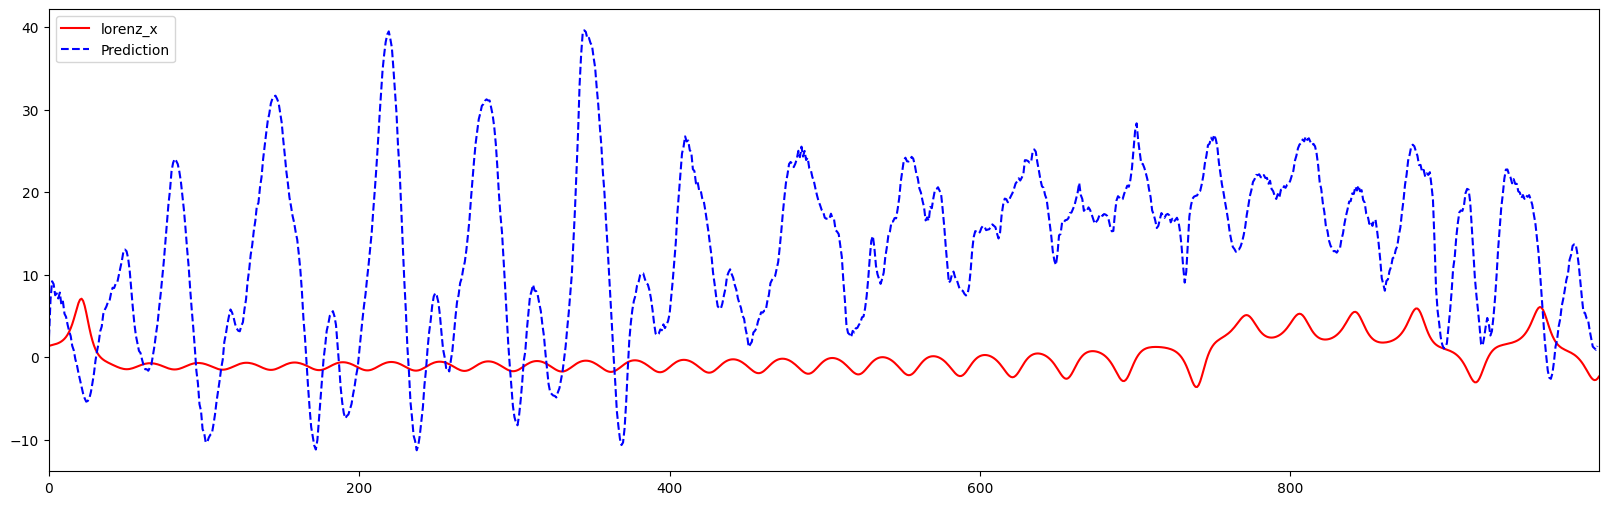

In [10]:
prediction = kernel_reservoir_prediction(r_train,r_test,lorenz,0.1)

targets_x = np.roll(lorenz,-2)
targets_x = targets_x[:-1]

#numer = np.mean(targets_x*prediction,0)
#denom = np.sqrt( np.mean(targets_x**2,0) * np.mean(prediction**2,0))
#R = numer/denom
#print(R)

print(prediction[0])

fig,ax = plt.subplots()
fig.set_size_inches(20,6)
ax.plot(lorenz[:,0],color='red',label='lorenz_x')
ax.plot(prediction,color='blue',linestyle='dashed',label='Prediction')
ax.set_xlim([0,len(prediction)])
plt.legend(loc="upper left")
plt.show() 